# EDA
**Предмет:** Софтверски алгоритми у системима аутоматског управљања
**Студент:** Марко Дурић РА 106-2023
**Тема:** Вишекласна класификација метал поджанрова на основу аудио карактеристика

---

### 1. Увоз библиотека и учитавање података

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.figsize"]=(10,6)

df = pd.read_csv("../data/processed/cleaned_data.csv")

### 2. Преглед облика и првих редова скупа података

In [2]:
print("Shape:", df.shape)

df.head()

Shape: (950, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre
0,2biGEMYnKkiqJXkS8Koiaw,Panopticon,Kentucky,Kentucky,18,201066,False,0.456,0.399,7,-16.311,1,0.0311,0.644000,0.656000,0.2310,0.6890,99.951,4,black-metal
1,0WTc2jsUgF4Y2MOz0aYvsR,Megadeth,Hidden Treasures,Paranoid,65,152600,True,0.355,0.973,4,-7.004,0,0.0710,0.000359,0.154000,0.1420,0.6280,187.385,4,thrash-metal
2,7aMY3p166A7gDvbugcE2Ao,Xandria,Ravenheart,Eversleeping,39,220040,False,0.501,0.339,7,-9.220,0,0.0300,0.905000,0.000105,0.1040,0.1330,130.026,4,symphonic-metal
3,3oxjWhYHcHE3xtrpQulOmd,Exodus,Pleasures of the Flesh,Seeds of Hate,22,297306,False,0.209,0.947,11,-5.313,1,0.1090,0.000002,0.197000,0.2470,0.2300,89.540,4,thrash-metal
4,3U9gogDStAfWxSm91PJuxb,Slayer,South Of Heaven,South Of Heaven,64,298533,True,0.310,0.991,5,-3.769,0,0.3160,0.000132,0.085000,0.0969,0.0395,140.071,4,thrash-metal


### 3. Информације о колонама и типовима података

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          950 non-null    str    
 1   artists           950 non-null    str    
 2   album_name        950 non-null    str    
 3   track_name        950 non-null    str    
 4   popularity        950 non-null    int64  
 5   duration_ms       950 non-null    int64  
 6   explicit          950 non-null    bool   
 7   danceability      950 non-null    float64
 8   energy            950 non-null    float64
 9   key               950 non-null    int64  
 10  loudness          950 non-null    float64
 11  mode              950 non-null    int64  
 12  speechiness       950 non-null    float64
 13  acousticness      950 non-null    float64
 14  instrumentalness  950 non-null    float64
 15  liveness          950 non-null    float64
 16  valence           950 non-null    float64
 17  tempo   

### 4. Провјера null вриједности

In [4]:
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
genre               0
dtype: int64

### 5. Дистрибуција жанрова

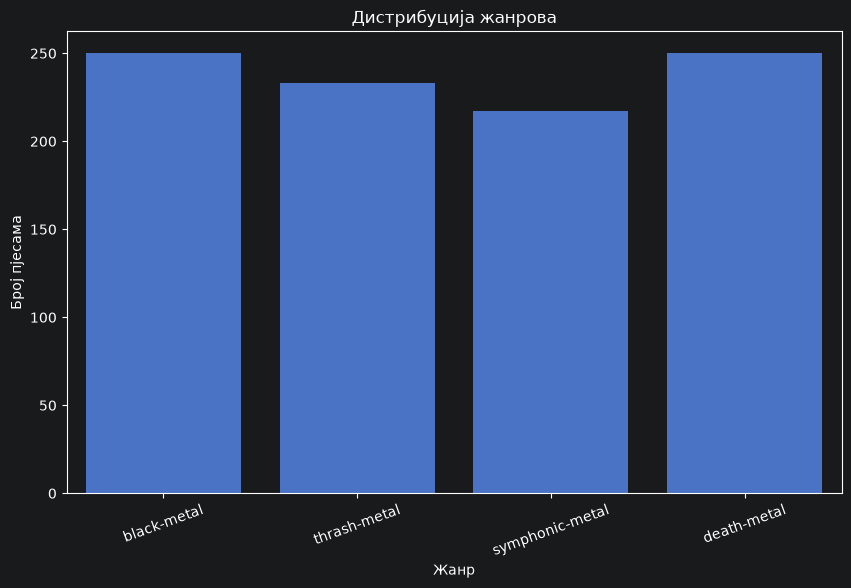

In [5]:
sns.countplot(
    data=df,
    x="genre"
)

plt.xticks(rotation=20)
plt.xlabel("Жанр")
plt.ylabel("Број пјесама")
plt.title("Дистрибуција жанрова")
plt.show()

### 6. Дистрибуција темпа

Text(0.5, 1.0, 'Дистрибуција темпа')

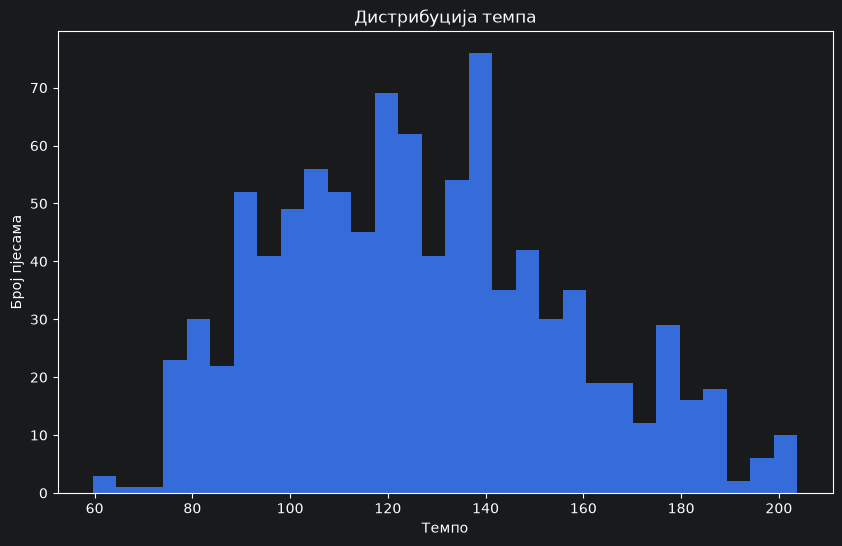

In [6]:
plt.hist(
    df["tempo"],
    bins=30
)

plt.xlabel("Темпо")
plt.ylabel("Број пјесама")
plt.title("Дистрибуција темпа")

### 7. Хистограми осталих аудио атрибута

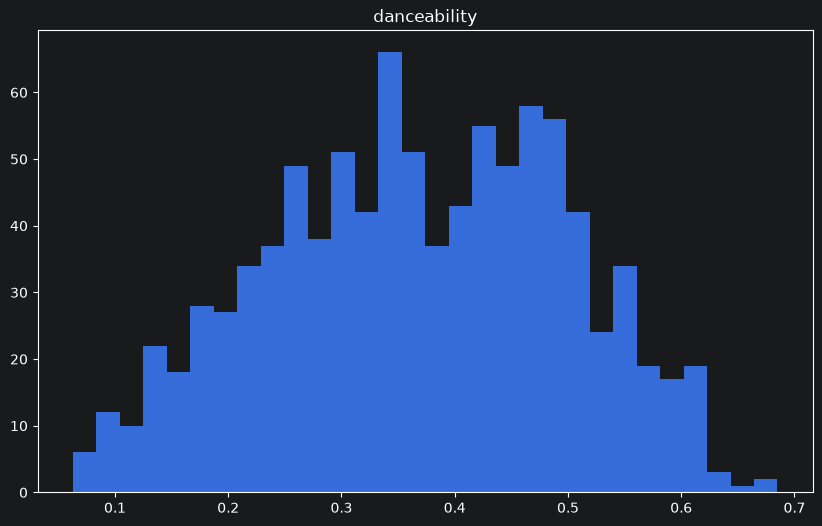

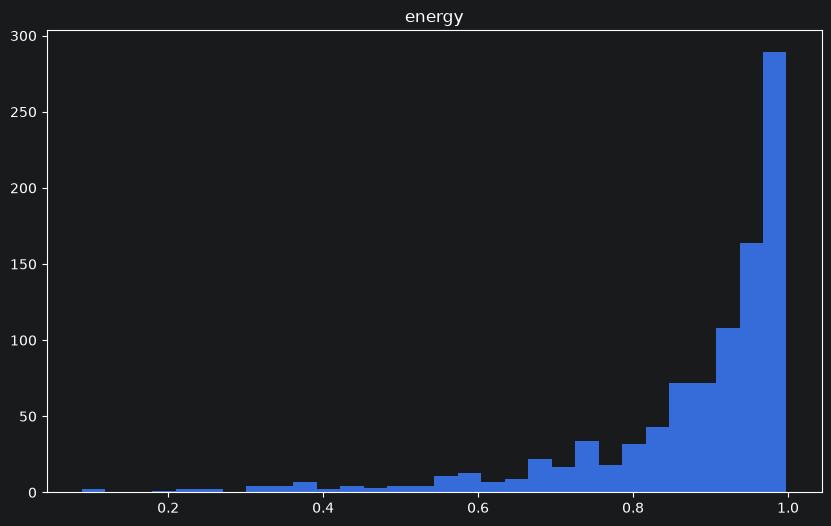

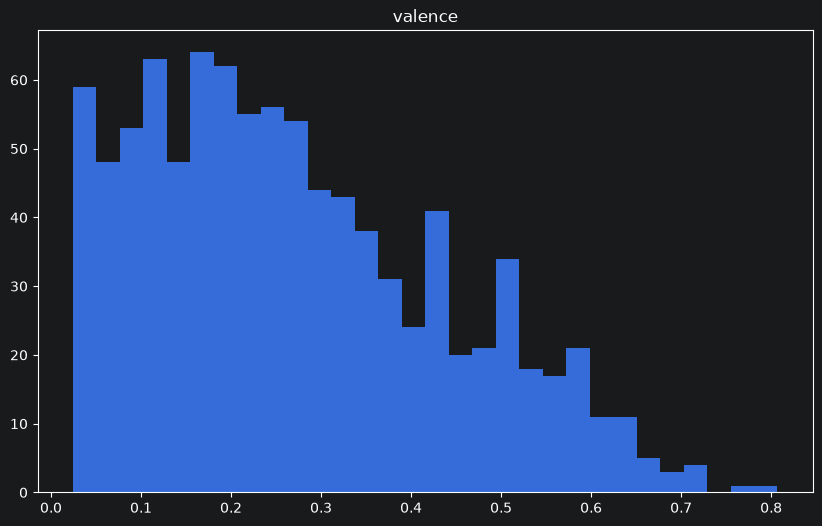

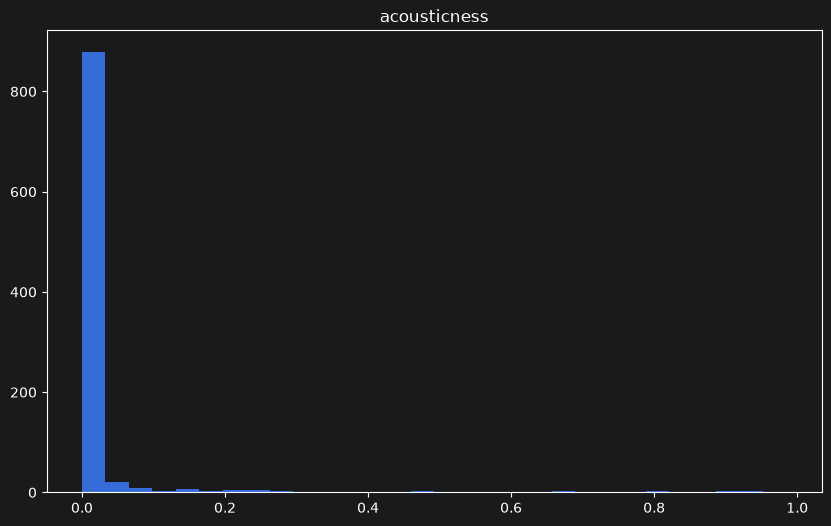

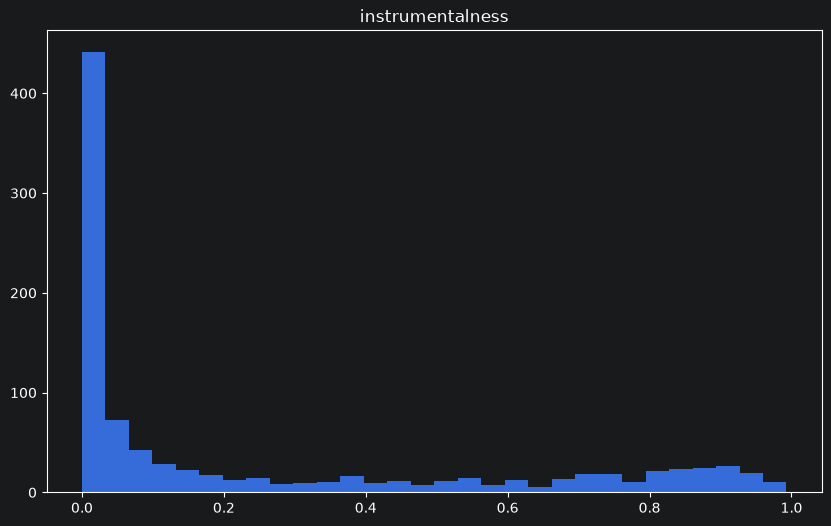

In [7]:
features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness"
]

for feature in features:

    plt.figure()

    plt.hist(df[feature], bins=30)

    plt.title(feature)

    plt.show()

### 8. Boxplot темпа по жанру

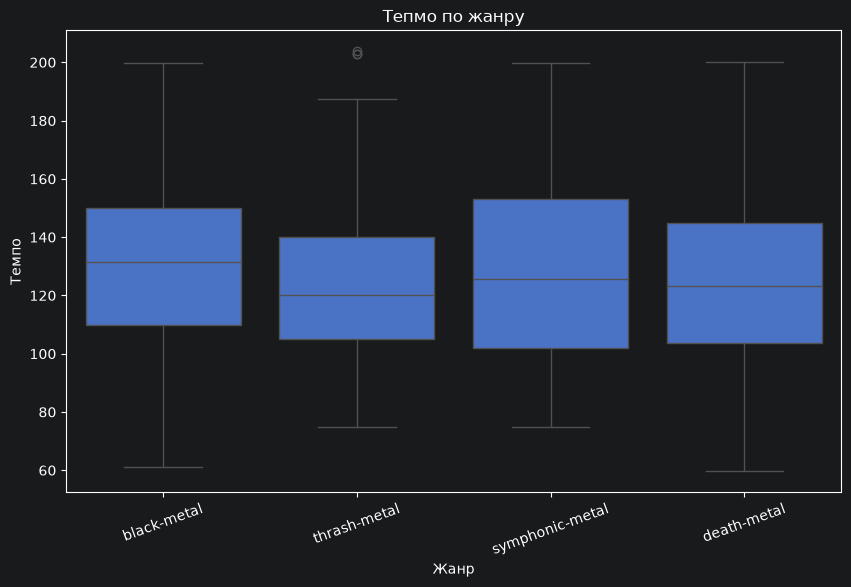

In [8]:
sns.boxplot(
    data=df,
    x="genre",
    y="tempo"
)

plt.xticks(rotation=20)

plt.xlabel("Жанр")
plt.ylabel("Темпо")
plt.title("Тепмо по жанру")
plt.show()

### 9. Boxplot енергије по жанру

Text(0.5, 1.0, 'Енергија по жанру')

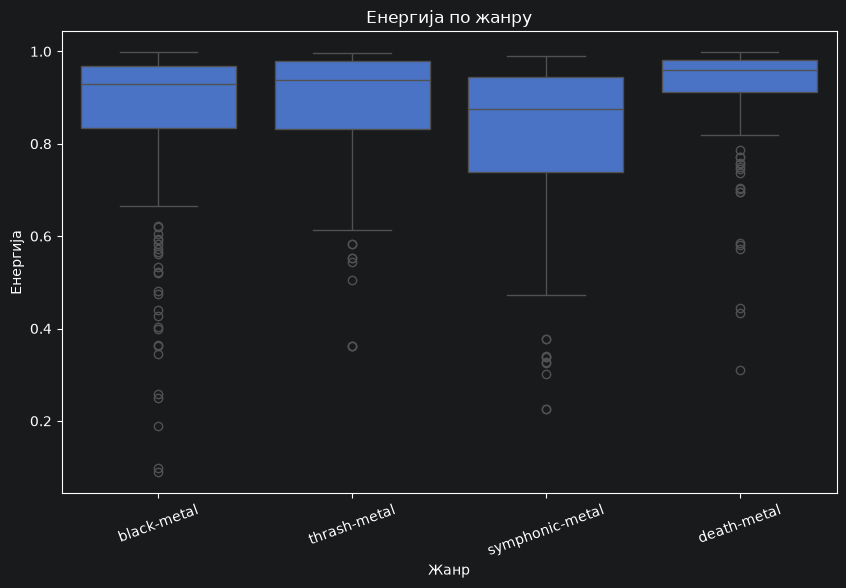

In [9]:
sns.boxplot(
    data=df,
    x="genre",
    y="energy"
)

plt.xticks(rotation=20)

plt.xlabel("Жанр")
plt.ylabel("Енергија")
plt.title("Енергија по жанру")

### 10. Корелациона матрица

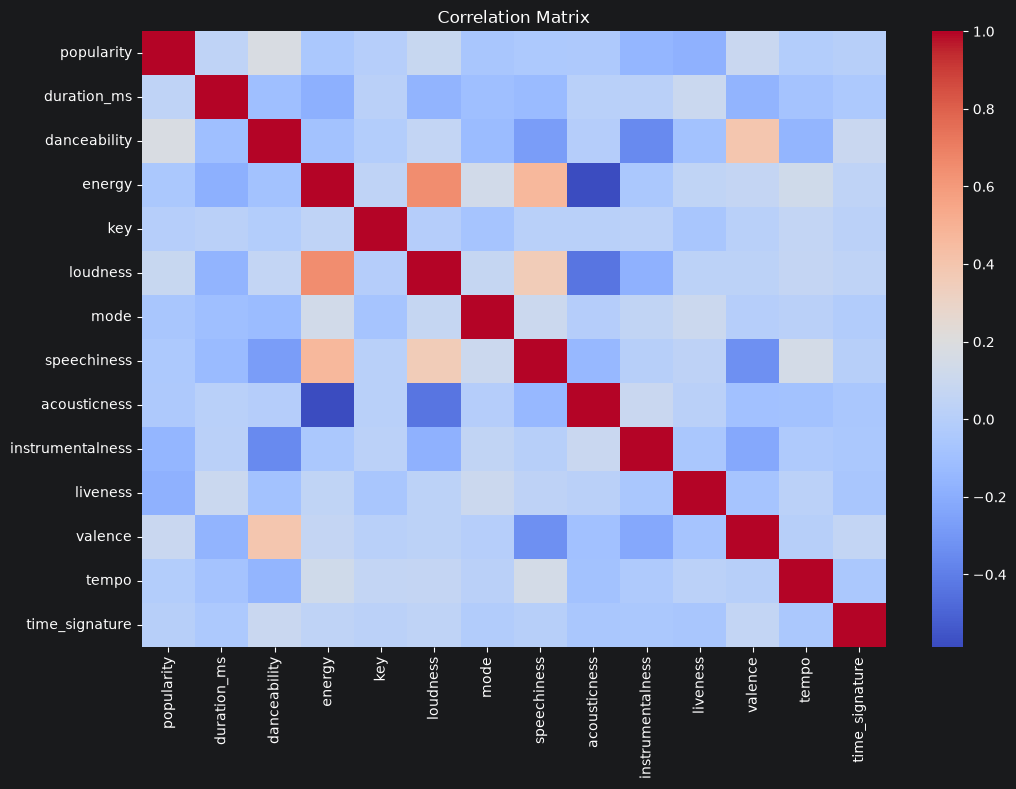

In [10]:
numeric = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### 11. Просјечне вриједности атрибута по жанру

In [11]:
df.groupby("genre")[[
    "tempo",
    "energy",
    "valence",
    "danceability",
    "acousticness"
]].mean()

,tempo,energy,valence,danceability,acousticness
genre,,,,,
black-metal,130.516856,0.861443,0.201190,0.295878,0.035153
death-metal,126.389204,0.927748,0.248002,0.363604,0.004617
symphonic-metal,127.211171,0.823230,0.319734,0.426493,0.052469
thrash-metal,123.674996,0.887944,0.328769,0.394952,0.007622


### 12. Pairplot кључних атрибута

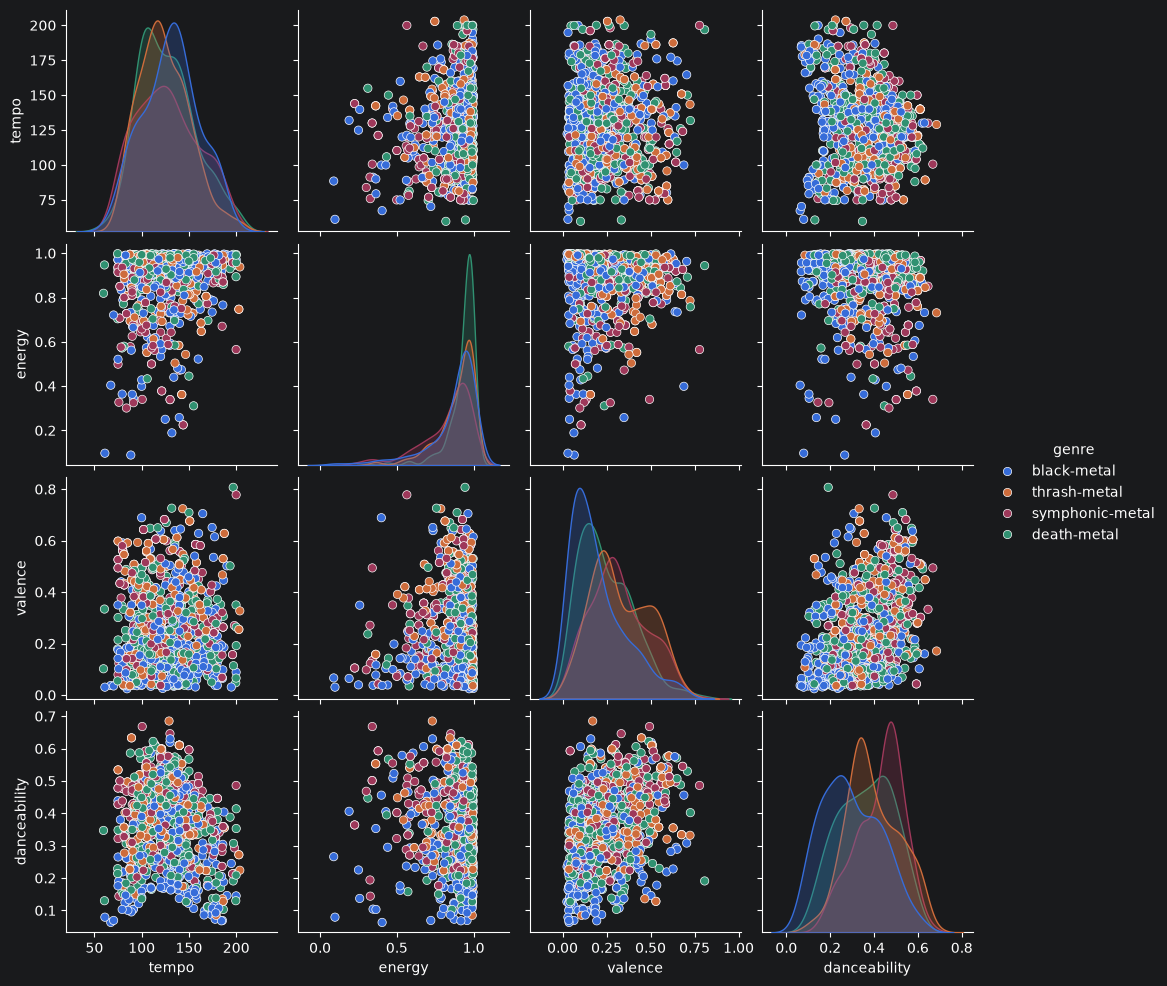

In [12]:
sns.pairplot(
    df,
    vars=[
        "tempo",
        "energy",
        "valence",
        "danceability"
    ],
    hue="genre"
)

plt.show()

### 13. Припрема – конверзија трајања и листа нумеричких атрибута

In [13]:
# Конверзија трајања из ms у секунде – прегледније за интерпретацију
df["duration_s"] = df["duration_ms"] / 1000

# Листа нумеричких атрибута релевантних за класификацију
features = [
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "speechiness", "liveness",
    "tempo", "loudness", "duration_s", "popularity"
]

genres = df["genre"].unique()
print("Жанрови: ", genres)
print("Укупно пјесама: ", len(df))

Жанрови:  <StringArray>
['black-metal', 'thrash-metal', 'symphonic-metal', 'death-metal']
Length: 4, dtype: str
Укупно пјесама:  950


### 14. Детекција outliera – IQR метода по жанру

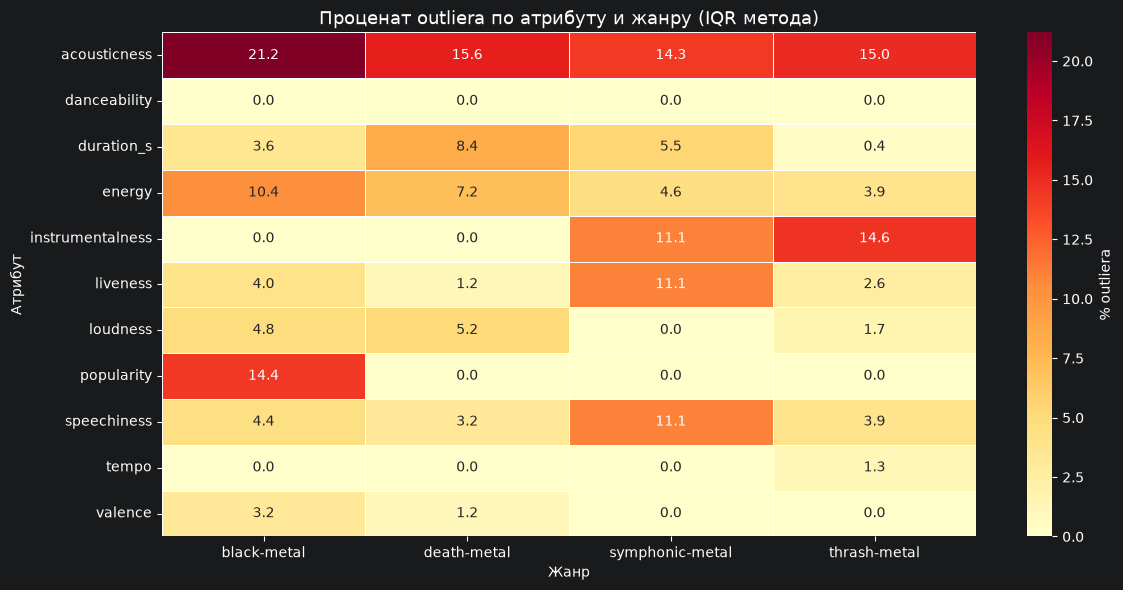

In [14]:
outlier_summary = []

for genre in genres:
    subset = df[df["genre"] == genre]
    for feat in features:
        Q1 = subset[feat].quantile(0.25)
        Q3 = subset[feat].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((subset[feat] < lower) | (subset[feat] > upper)).sum()
        outlier_pct = n_outliers / len(subset) * 100
        outlier_summary.append({
            "genre": genre,
            "feature": feat,
            "n_outliers": n_outliers,
            "outlier_pct": round(outlier_pct, 2)
        })

outlier_df = pd.DataFrame(outlier_summary)

# Pivot табела – проценат outliera по атрибуту и жанру
pivot = outlier_df.pivot(index="feature", columns="genre", values="outlier_pct")

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "% outliera"}
)
plt.title("Проценат outliera по атрибуту и жанру (IQR метода)", fontsize=13)
plt.xlabel("Жанр")
plt.ylabel("Атрибут")
plt.tight_layout()
plt.show()

### 15. Violin plotovi – дистрибуција кључних атрибута по жанру

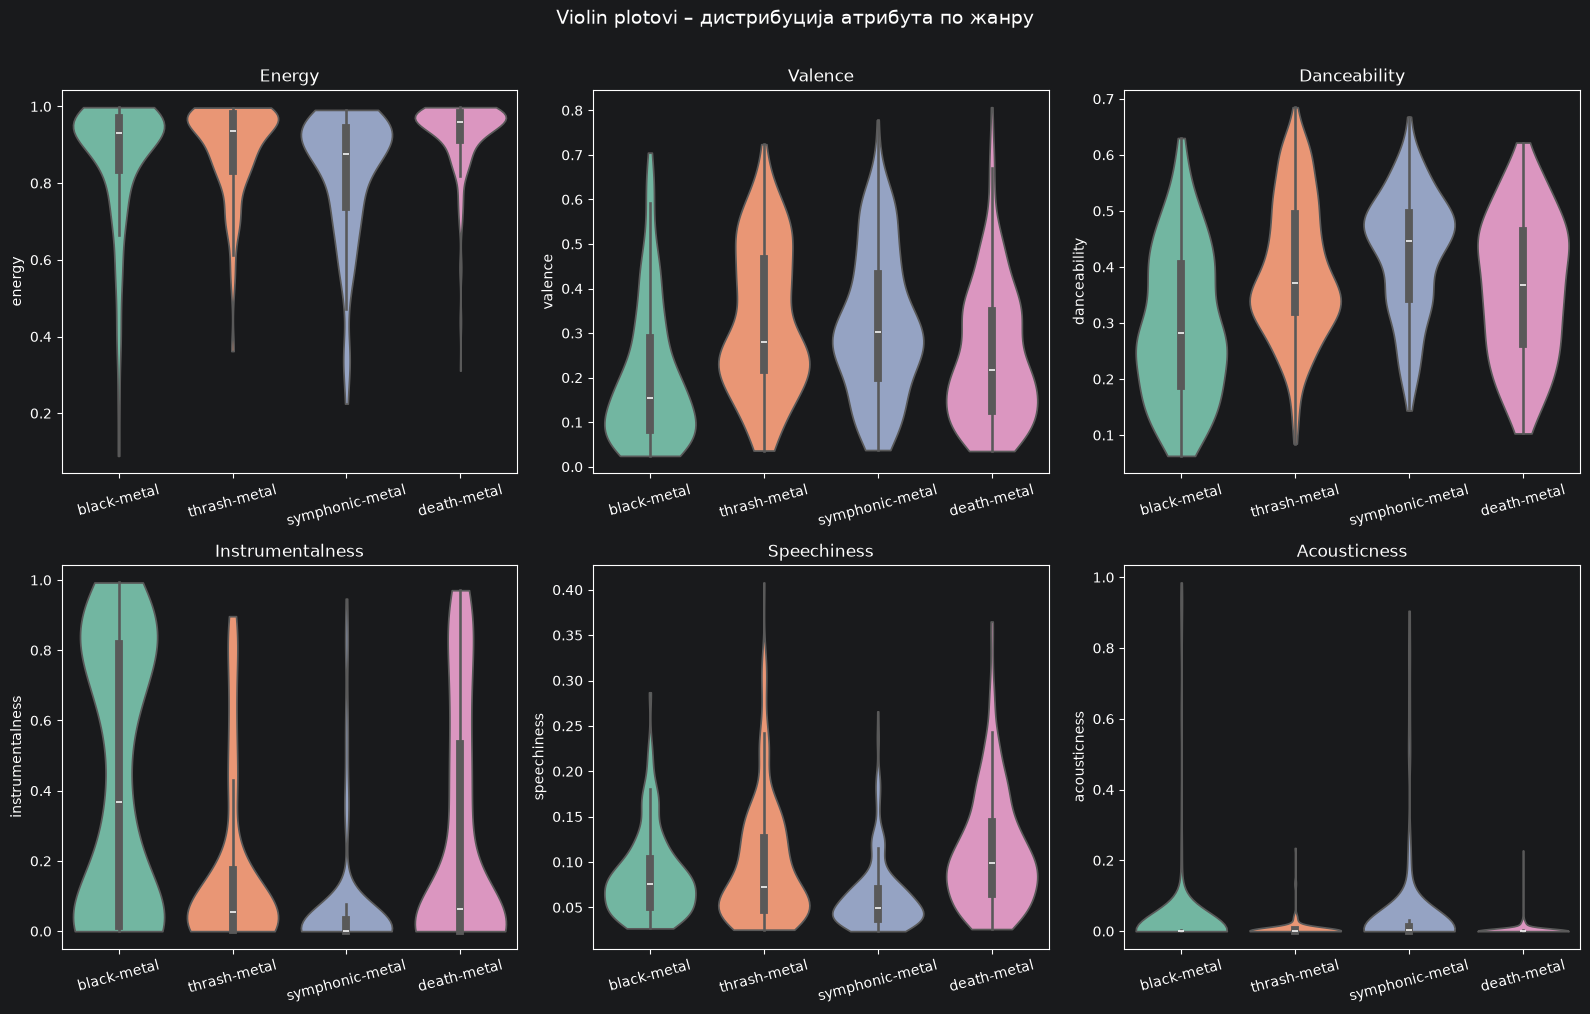

In [15]:
# Violin plotovi су информативнији од boxplotova – показују облик дистрибуције,


violin_features = ["energy", "valence", "danceability", "instrumentalness", "speechiness", "acousticness"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(violin_features):
    sns.violinplot(
        data=df,
        x="genre",
        y=feat,
        ax=axes[i],
        hue="genre",
        palette="Set2",
        legend=False,
        inner="box",
        cut=0
    )
    axes[i].set_title(feat.capitalize(), fontsize=12)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Violin plotovi – дистрибуција атрибута по жанру", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 16. KDE plotovi – преклапање дистрибуција између жанрова

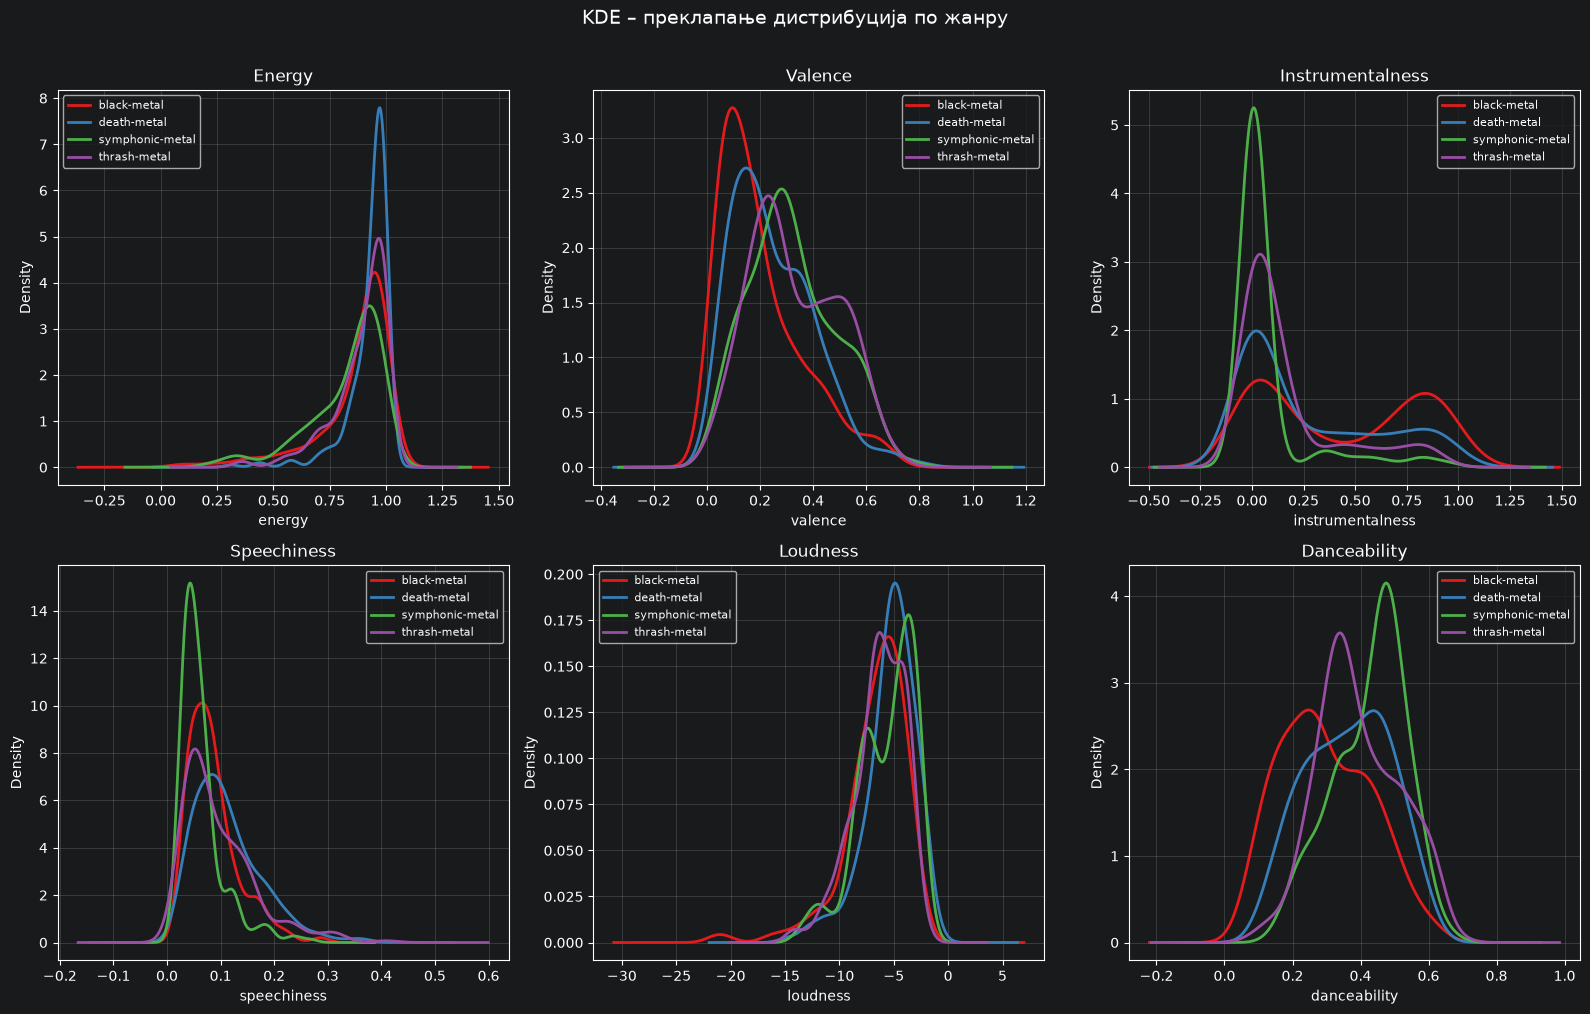

In [16]:
# KDE plotovi показују гдје се класе преклапају

kde_features = ["energy", "valence", "instrumentalness", "speechiness", "loudness", "danceability"]
palette = sns.color_palette("Set1", n_colors=len(genres))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(kde_features):
    for j, genre in enumerate(sorted(genres)):
        subset = df[df["genre"] == genre][feat]
        subset.plot.kde(ax=axes[i], label=genre, color=palette[j], linewidth=2)
    axes[i].set_title(feat.capitalize(), fontsize=12)
    axes[i].set_xlabel(feat)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle("KDE – преклапање дистрибуција по жанру", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 17. Feature importance – ANOVA F-тест

         feature  F-score  p-value significant
instrumentalness    62.04   0.0000           ✓
    danceability    49.62   0.0000           ✓
         valence    35.14   0.0000           ✓
      popularity    34.38   0.0000           ✓
     speechiness    31.42   0.0000           ✓
          energy    22.41   0.0000           ✓
        liveness    16.23   0.0000           ✓
        loudness    13.91   0.0000           ✓
      duration_s    11.83   0.0000           ✓
    acousticness     9.83   0.0000           ✓
           tempo     2.20   0.0868           ✗


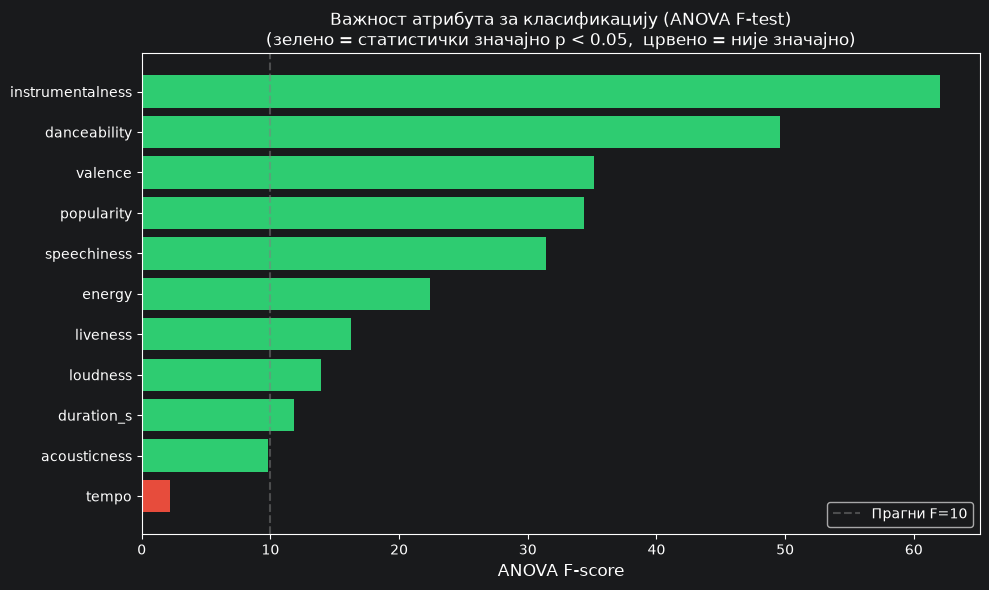

In [17]:
from scipy import stats


# Виши F-score → атрибут је кориснији за класификацију
df["duration_s"] = df["duration_ms"] / 1000

anova_results = []

for feat in features:
    groups = [df[df["genre"] == g][feat].dropna() for g in genres]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({
        "feature": feat,
        "F-score": round(f_stat, 2),
        "p-value": round(p_val, 4),
        "significant": "✓" if p_val < 0.05 else "✗"
    })

anova_df = pd.DataFrame(anova_results).sort_values("F-score", ascending=False)
print(anova_df.to_string(index=False))

# Визуализација
plt.figure(figsize=(10, 6))
colors = ["#2ecc71" if p < 0.05 else "#e74c3c" for p in anova_df["p-value"]]
bars = plt.barh(anova_df["feature"], anova_df["F-score"], color=colors)
plt.xlabel("ANOVA F-score", fontsize=12)
plt.title("Важност атрибута за класификацију (ANOVA F-test)\n(зелено = статистички значајно p < 0.05,  црвено = није значајно)", fontsize=12)
plt.gca().invert_yaxis()
plt.axvline(x=10, color="gray", linestyle="--", alpha=0.5, label="Прагни F=10")
plt.legend()
plt.tight_layout()
plt.show()

### 18. Категоричке варијабле – `explicit` и `mode` по жанру

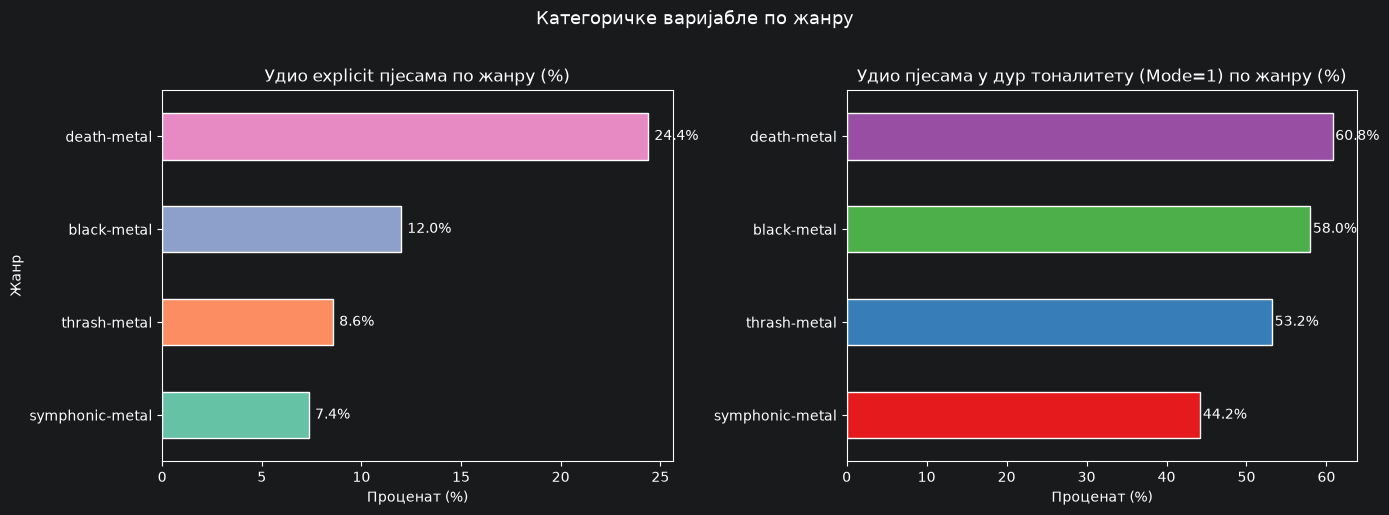

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Explicit по жанру ---
explicit_pct = df.groupby("genre")["explicit"].mean() * 100
explicit_pct.sort_values().plot(
    kind="barh",
    ax=axes[0],
    color=sns.color_palette("Set2", 4),
    edgecolor="white"
)
axes[0].set_title("Удио explicit пјесама по жанру (%)", fontsize=12)
axes[0].set_xlabel("Проценат (%)")
axes[0].set_ylabel("Жанр")
for i, v in enumerate(explicit_pct.sort_values()):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)

# --- Mode (Major/Minor) по жанру ---
mode_pct = df.groupby("genre")["mode"].mean() * 100
mode_pct.sort_values().plot(
    kind="barh",
    ax=axes[1],
    color=sns.color_palette("Set1", 4),
    edgecolor="white"
)
axes[1].set_title("Удио пјесама у дур тоналитету (Mode=1) по жанру (%)", fontsize=12)
axes[1].set_xlabel("Проценат (%)")
axes[1].set_ylabel("")
for i, v in enumerate(mode_pct.sort_values()):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)

plt.suptitle("Категоричке варијабле по жанру", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 19. Radar chart – просјечни профил сваког жанра

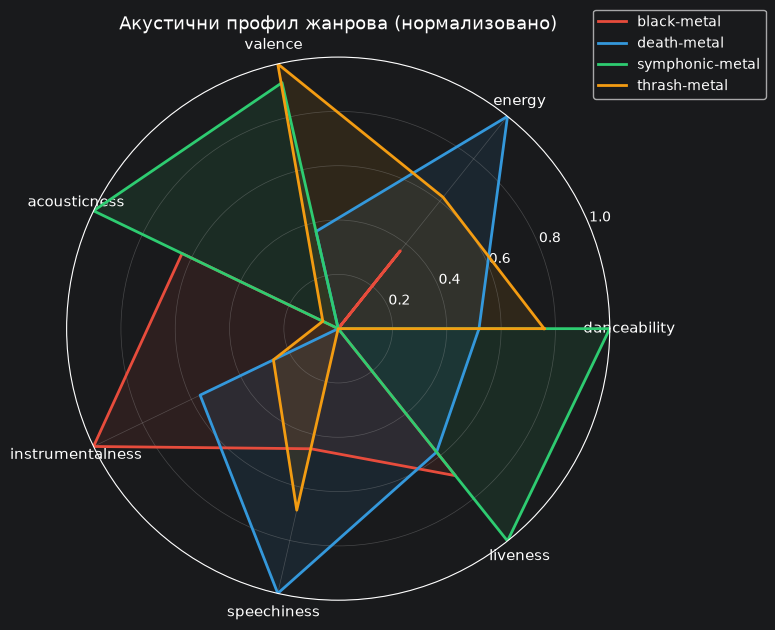

In [19]:
from matplotlib.patches import FancyArrowPatch

# Radar chart показује "акустични профил" сваког жанра у односу на остале

radar_features = ["danceability", "energy", "valence", "acousticness",
                  "instrumentalness", "speechiness", "liveness"]

# Нормализација на [0, 1] за поређење
means = df.groupby("genre")[radar_features].mean()
means_norm = (means - means.min()) / (means.max() - means.min())

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Затварање полигона

colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, (genre, row) in enumerate(means_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=genre)
    ax.fill(angles, values, color=colors[idx], alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Акустични профил жанрова (нормализовано)", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 20. Закључци EDA анализе

In [20]:
print("="*60)
print("ЗАКЉУЧЦИ EDA АНАЛИЗЕ")
print("="*60)
print()
print("► Скуп података: 950 пјесама, 4 жанра, без null вриједности")
print()
print("► Баланс класа:")
for genre, count in df["genre"].value_counts().items():
    print(f"   {genre}: {count} ({count/len(df)*100:.1f}%)")
print()
print("► Најважнији атрибути за класификацију (ANOVA):")
top = anova_df[anova_df["p-value"] < 0.05].head(5)
for _, row in top.iterrows():
    print(f"   {row['feature']}: F={row['F-score']}")
print()
print("► Статистички незначајан атрибут: tempo (p > 0.05)")
print("   → Разматрати искључивање темпа из модела")
print()
print("► Уочено преклапање класа:")
print("   thrash vs death metal – слична енергија и гласноћа")
print("   symphonic metal – јасно издвојен по valence и danceability")
print("   black metal – висока instrumentalness, низак speechiness")

ЗАКЉУЧЦИ EDA АНАЛИЗЕ

► Скуп података: 950 пјесама, 4 жанра, без null вриједности

► Баланс класа:
   black-metal: 250 (26.3%)
   death-metal: 250 (26.3%)
   thrash-metal: 233 (24.5%)
   symphonic-metal: 217 (22.8%)

► Најважнији атрибути за класификацију (ANOVA):
   instrumentalness: F=62.04
   danceability: F=49.62
   valence: F=35.14
   popularity: F=34.38
   speechiness: F=31.42

► Статистички незначајан атрибут: tempo (p > 0.05)
   → Разматрати искључивање темпа из модела

► Уочено преклапање класа:
   thrash vs death metal – слична енергија и гласноћа
   symphonic metal – јасно издвојен по valence и danceability
   black metal – висока instrumentalness, низак speechiness
